In [331]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('co2.csv')

1. Exploratory Data Analysis

In [332]:
print(df.head())
print(df.tail())
print(df.shape)


    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

In [333]:
print(df.columns)
print(df.describe())

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='str')
       Engine Size(L)    Cylinders  Fuel Consumption City (L/100 km)  \
count     7385.000000  7385.000000                       7385.000000   
mean         3.160068     5.615030                         12.556534   
std          1.354170     1.828307                          3.500274   
min          0.900000     3.000000                          4.200000   
25%          2.000000     4.000000                         10.100000   
50%          3.000000     6.000000                         12.100000   
75%          3.700000     6.000000                         14.600000   
max          8.400000    16.000000                         30.600000   

       Fuel Consumption Hwy (L/100 km)  Fuel Con

In [334]:
missing_percent = df.isnull().mean() * 100

print(missing_percent[missing_percent > 0])

Series([], dtype: float64)


In [335]:
print(df.duplicated().sum())

1103


In [336]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates)

              Make       Model            Vehicle Class  Engine Size(L)  \
4            ACURA     RDX AWD              SUV - SMALL             3.5   
5            ACURA         RLX                 MID-SIZE             3.5   
12      ALFA ROMEO          4C               TWO-SEATER             1.8   
13    ASTON MARTIN         DB9              MINICOMPACT             5.9   
15    ASTON MARTIN  V8 VANTAGE               TWO-SEATER             4.7   
...            ...         ...                      ...             ...   
7356        TOYOTA      Tundra  PICKUP TRUCK - STANDARD             5.7   
7365    VOLKSWAGEN    Golf GTI                  COMPACT             2.0   
7366    VOLKSWAGEN       Jetta                  COMPACT             1.4   
7367    VOLKSWAGEN       Jetta                  COMPACT             1.4   
7368    VOLKSWAGEN   Jetta GLI                  COMPACT             2.0   

      Cylinders Transmission Fuel Type  Fuel Consumption City (L/100 km)  \
4             6        

In [337]:
numerical_columns = df.select_dtypes(include='number').columns
print(numerical_columns)

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='str')


In [338]:
fuel_types = df["Fuel Type"].value_counts()

print(fuel_types)

Fuel Type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64


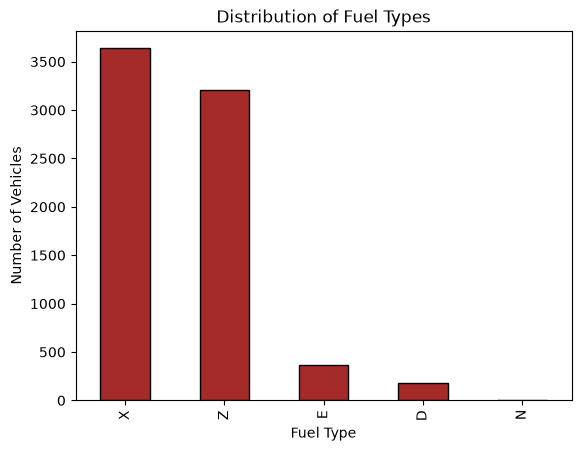

In [339]:
df["Fuel Type"].value_counts().plot(kind="bar",  color = 'brown', edgecolor = 'black')

plt.xlabel("Fuel Type")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Fuel Types")

plt.show()

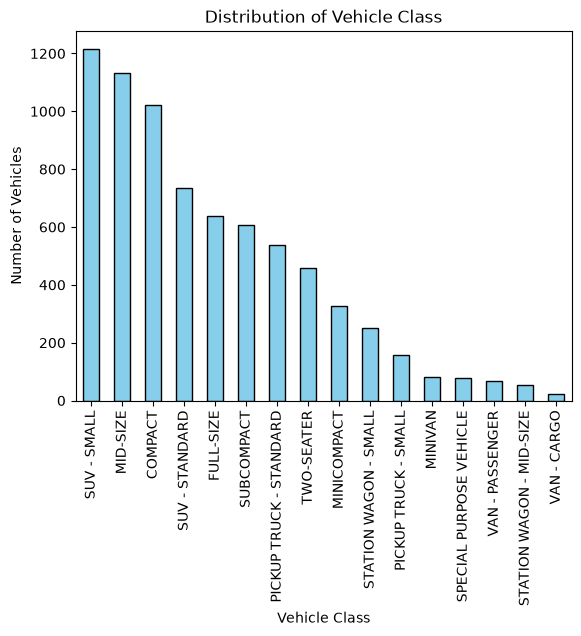

In [340]:
df["Vehicle Class"].value_counts().plot(kind="bar", color = 'skyblue', edgecolor = 'black')

plt.xlabel("Vehicle Class")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Class")

plt.show()

In [341]:
print(df["Model"].nunique())
print(df["Make"].nunique())

2053
42


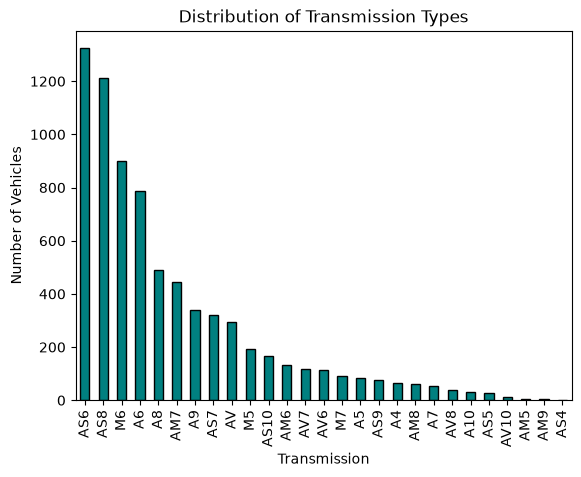

In [342]:
df["Transmission"].value_counts().plot(kind="bar", color = 'teal', edgecolor = 'black')
plt.xlabel("Transmission")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Transmission Types")

plt.show()

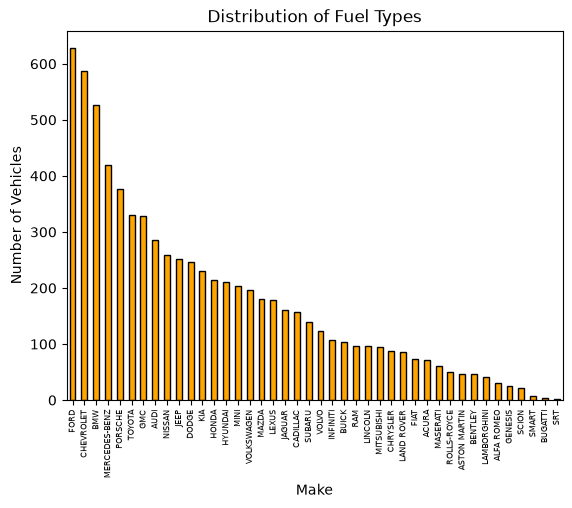

In [343]:
df["Make"].value_counts().plot(kind="bar", color = 'orange', edgecolor = 'black')
plt.xlabel("Make")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Fuel Types")
plt.xticks(fontsize=6)

plt.show()

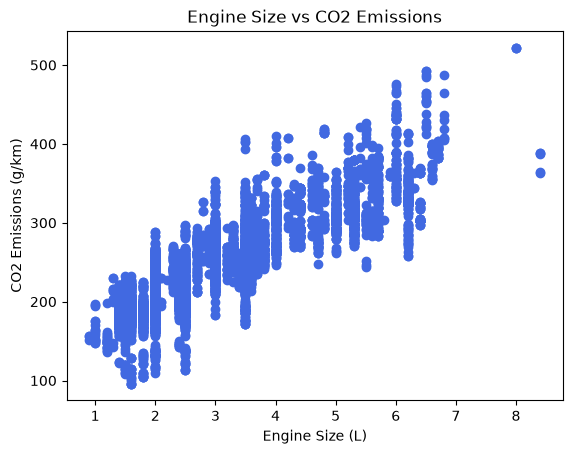

In [344]:
plt.scatter(
    df["Engine Size(L)"],
    df["CO2 Emissions(g/km)"], color = 'royalblue'
)

plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Engine Size vs CO2 Emissions")

plt.show()

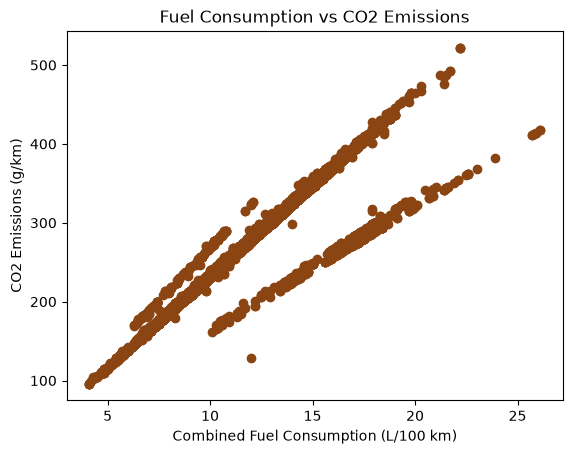

In [345]:
plt.scatter(
    df["Fuel Consumption Comb (L/100 km)"],
    df["CO2 Emissions(g/km)"], color = 'saddlebrown'
)

plt.xlabel("Combined Fuel Consumption (L/100 km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Fuel Consumption vs CO2 Emissions")

plt.show()

In [346]:
correlations = df[numerical_columns].corr()["CO2 Emissions(g/km)"]

print(correlations.sort_values(ascending=False))

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


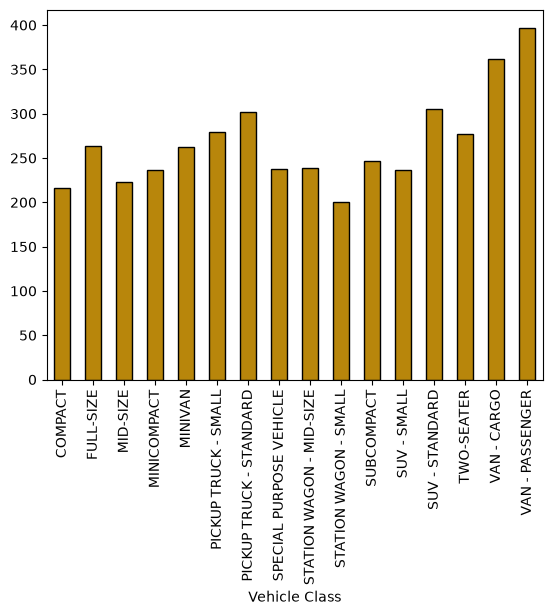

In [347]:
df.groupby("Vehicle Class")["CO2 Emissions(g/km)"].mean().plot(kind = 'bar',  color = 'darkgoldenrod', edgecolor = 'black')
plt.show()

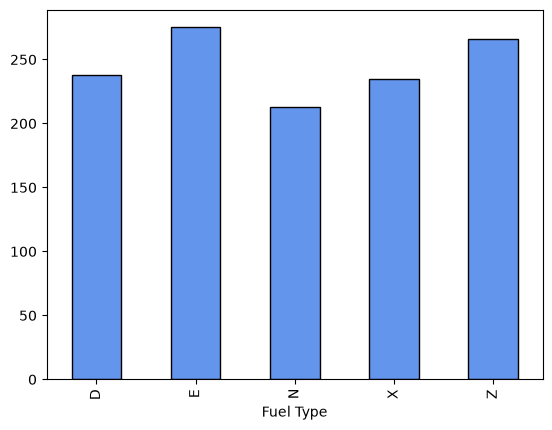

In [348]:
df.groupby("Fuel Type")["CO2 Emissions(g/km)"].mean().plot(kind = 'bar',  color = 'cornflowerblue', edgecolor = 'black')
plt.show()

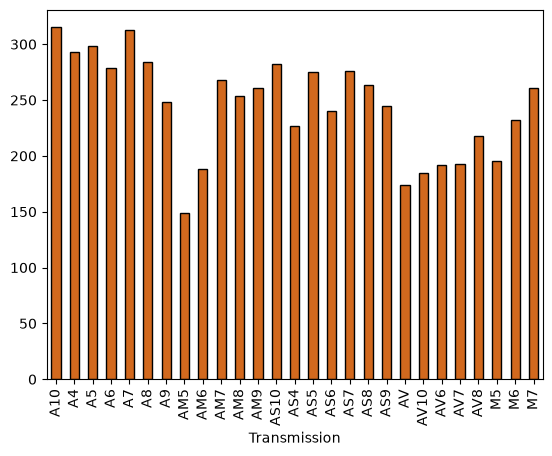

In [349]:
df.groupby("Transmission")["CO2 Emissions(g/km)"].mean().plot(kind = 'bar',  color = 'chocolate', edgecolor = 'black')
plt.show()

2. Linear Regression